In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import random
random.seed(42)
np.random.seed(42)

In [2]:
df = pd.read_csv("wine-clustering.csv")

df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
X = df.copy()
numerical_cols = X.columns.tolist()

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [5]:
# Create preprocessing pipeline
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

processor = ColumnTransformer(transformers=[
    ("num", num_pipe, numerical_cols)
], remainder="drop")

# Fit and transform the data
X_processed = processor.fit_transform(X)

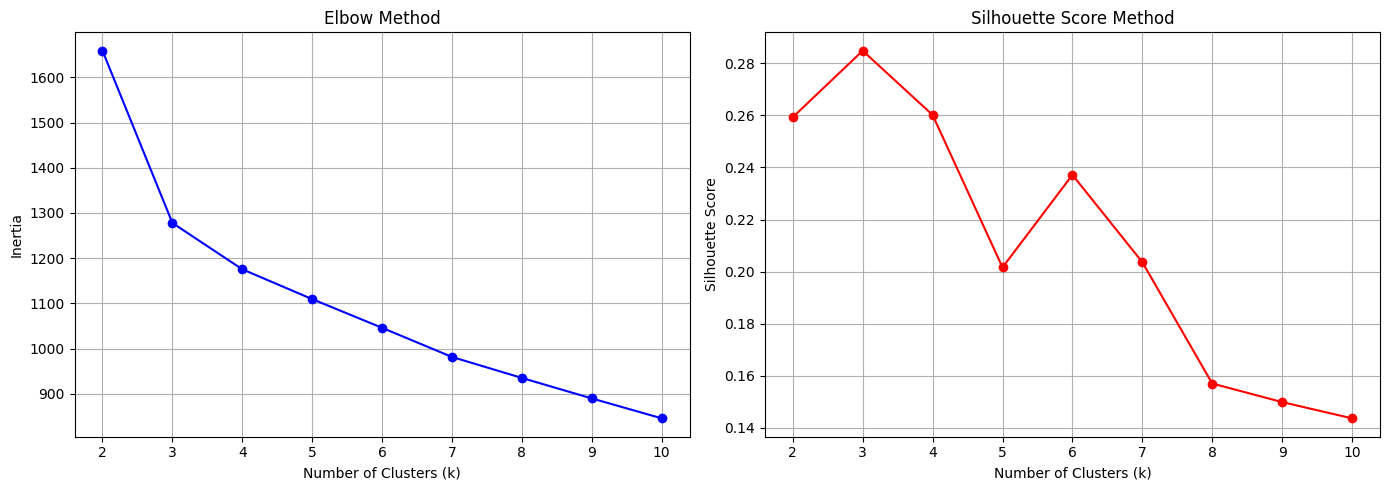

Optimal k based on silhouette score: 3


In [6]:
# Determine optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, kmeans.labels_))

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True)

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score Method')
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Optimal k based on silhouette score:", K_range[np.argmax(silhouette_scores)])

In [7]:
# Apply KMeans with optimal number of clusters
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Applying KMeans with k={optimal_k}")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_processed)

# Add cluster labels to dataframe
df["Cluster"] = cluster_labels

Applying KMeans with k=3


In [8]:
# Display cluster distribution
print("Cluster distribution:")
print(df["Cluster"].value_counts().sort_index())
print(f"\nSilhouette Score: {silhouette_score(X_processed, cluster_labels):.4f}")

Cluster distribution:
Cluster
0    65
1    51
2    62
Name: count, dtype: int64

Silhouette Score: 0.2849


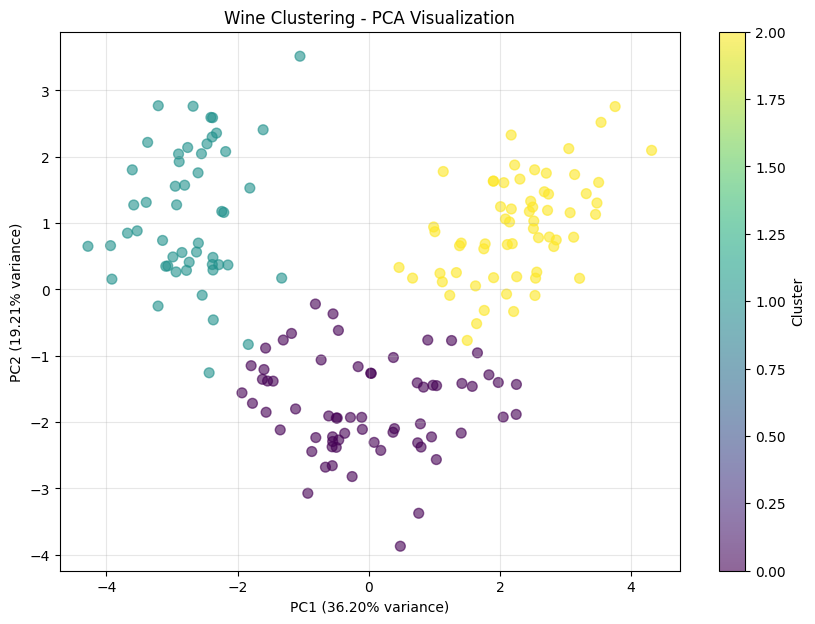

In [9]:
# Visualize clusters using PCA for dimensionality reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Wine Clustering - PCA Visualization')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Create submission file
submission = pd.DataFrame({
    "Id": df.index,
    "Cluster": df["Cluster"]
})

submission.to_csv("submission.csv", index=False)
print("Submission file created successfully!")
print(f"\nSubmission preview:")
print(submission.head(10))

Submission file created successfully!

Submission preview:
   Id  Cluster
0   0        2
1   1        2
2   2        2
3   3        2
4   4        2
5   5        2
6   6        2
7   7        2
8   8        2
9   9        2
